In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
x = np.array([
    1 * 30.44,         # 1 Mo
    1.5 * 30.44,       # 1.5 Mo
    2 * 30.44,         # 2 Mo
    3 * 30.44,         # 3 Mo
    4 * 30.44,         # 4 Mo
    6 * 30.44,         # 6 Mo
    1 * 365.25,        # 1 Yr
    2 * 365.25,        # 2 Yr
    3 * 365.25,        # 3 Yr
    5 * 365.25,        # 5 Yr
    7 * 365.25,        # 7 Yr
    10 * 365.25,       # 10 Yr
    20 * 365.25,       # 20 Yr
    30 * 365.25        # 30 Yr
])

y = np.array([4.37, 4.46, 4.45, 4.41, 4.42, 4.30, 4.05, 3.83, 3.77,
                      3.88, 4.09, 4.35, 4.90, 4.90]) / 100

[4.22849495e-06]
(14, 3)
[3.85797617e-06]
(14, 3)
[3.95762229e-06]
(14, 3)


/var/folders/q5/rll74k_j0qs7l4zzzgg749km0000gn/T/ipykernel_32710/1222629964.py:20: RuntimeWarning: invalid value encountered in divide
  return betas[0] + betas[1] * (1 - np.exp(-t / tau)) / (t / tau) + betas[2] * ((1 - np.exp(-1 * t / tau)) / (t / tau) - np.exp(-1 * t / tau))


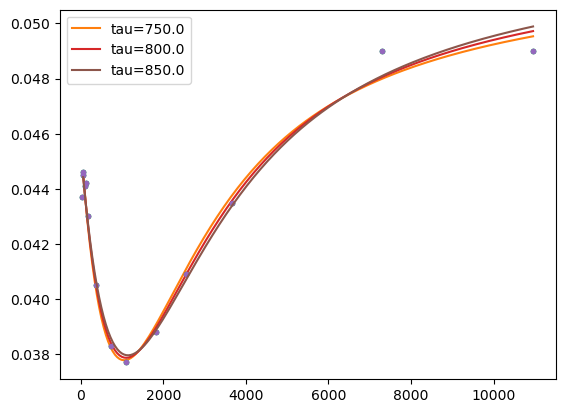

In [3]:
taus = np.linspace(750, 850, 3)

for tau in taus:
    # 
    # X = np.ndarray()
    X = []
    for xi in x:
        X.append(np.array([
            1,
            (1 - np.exp(-1 * xi / tau)) / (xi / tau),
            ((1 - np.exp(-1 * xi / tau)) / (xi / tau) - np.exp(-1 * xi / tau))
        ]))
    fit = np.linalg.lstsq(X, y)
    betas = fit[0]
    print(fit[1])

    print(np.array(X).shape)

    def predict(t):
        return betas[0] + betas[1] * (1 - np.exp(-t / tau)) / (t / tau) + betas[2] * ((1 - np.exp(-1 * t / tau)) / (t / tau) - np.exp(-1 * t / tau))


    plt.plot(x, y, '.')
    test_x = np.linspace(0, 30 * 365.25, 200)
    plt.plot(test_x, predict(test_x), label=f'tau={tau}')
    plt.legend()
# ns = beta0 + 
#                 beta1 * (1 - np.exp(-t / tau)) / (t / tau) + 
#                 beta2 * (np.exp(-t / tau))

[2.69707727e-06]
(14, 4)


/var/folders/q5/rll74k_j0qs7l4zzzgg749km0000gn/T/ipykernel_32710/2459846787.py:22: RuntimeWarning: invalid value encountered in divide
  return betas[0] + betas[1] * (1 - np.exp(-t / tau)) / (t / tau) + betas[2] * ((1 - np.exp(-1 * t / tau)) / (t / tau) - np.exp(-1 * t / tau)) + betas[3] * ((1 - np.exp(-1 * t / tau2)) / (t / tau2) - np.exp(-1 * t / tau2))


[2.12533917e-06]
(14, 4)
[1.9257538e-06]
(14, 4)


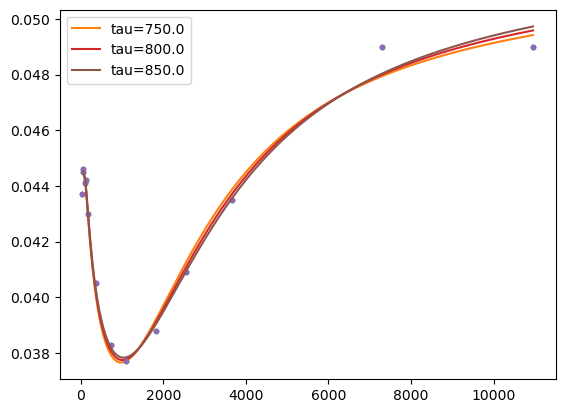

In [4]:
taus = np.linspace(750, 850, 3)
tau2 = 50

for tau in taus:
    # 
    # X = np.ndarray()
    X = []
    for xi in x:
        X.append(np.array([
            1,
            (1 - np.exp(-1 * xi / tau)) / (xi / tau),
            ((1 - np.exp(-1 * xi / tau)) / (xi / tau) - np.exp(-1 * xi / tau)),
            ((1 - np.exp(-1 * xi / tau2)) / (xi / tau2) - np.exp(-1 * xi / tau2))
        ]))
    fit = np.linalg.lstsq(X, y)
    betas = fit[0]
    print(fit[1])

    print(np.array(X).shape)

    def predict(t):
        return betas[0] + betas[1] * (1 - np.exp(-t / tau)) / (t / tau) + betas[2] * ((1 - np.exp(-1 * t / tau)) / (t / tau) - np.exp(-1 * t / tau)) + betas[3] * ((1 - np.exp(-1 * t / tau2)) / (t / tau2) - np.exp(-1 * t / tau2))


    plt.plot(x, y, '.')
    test_x = np.linspace(0, 30 * 365.25, 200)
    plt.plot(test_x, predict(test_x), label=f'tau={tau}')
    plt.legend()
# ns = beta0 + 
#                 beta1 * (1 - np.exp(-t / tau)) / (t / tau) + 
#                 beta2 * (np.exp(-t / tau))

In [5]:
from fixed_income.bond import Bond
from fixed_income.risk import *

In [ ]:
import pandas as pd
import xml.etree.ElementTree as ET
import requests
from io import BytesIO

url = ("https://home.treasury.gov/resource-center/data-chart-center/"
       "interest-rates/pages/xml?data=daily_treasury_yield_curve&field_tdr_date_value=all")
https://home.treasury.gov/resource-center/data-chart-center/interest-rates/daily-treasury-rates.csv/2025/all?type=daily_treasury_yield_curve&field_tdr_date_value=2025&page&_format=csv

resp = requests.get(url)
resp.raise_for_status()
print(resp)
tree = ET.parse(BytesIO(resp.content))
root = tree.getroot()
print(root)
# Parse XML entries (adjust namespace if needed)
data = []
for entry in root.findall(".//entry"):
    rec = {}
    # Example: <d:NEW_DATE>2025-07-23</d:NEW_DATE>
    for child in entry:
        print(child)
        break
        tag = child.tag.split('}')[-1]
        rec[tag] = child.text
    data.append(rec)

df = pd.DataFrame(data)
print(df)
# df['NEW_DATE'] = pd.to_datetime(df['NEW_DATE'])
# df.set_index('NEW_DATE', inplace=True)
# df = df.apply(pd.to_numeric, errors='coerce')

# print(df.iloc[-1])


<Response [200]>
<Element '{http://www.w3.org/2005/Atom}feed' at 0x167f2a110>
Empty DataFrame
Columns: []
Index: []
